In [7]:
import yfinance as yf
import pandas as pd

def update_database():
    # 1. Define the tickers
    # BTC-USD is for Bitcoin, SVXY for short volatility
    tickers = {
        'SPY': 'SPY - stocks',
        'GLD': 'GLD - gold',
        'DBC': 'DBC - commodities',
        'IEF': 'IEF - intermediate bonds',
        'TLT': 'TLT - long term bonds',
        'BTC-USD': 'btc',
        'SVXY': 'svxy'
    }

    print("Downloading Total Return data (Adjusted for Dividends)...")
    # auto_adjust=True pulls the dividend-reinvested prices
    data = yf.download(list(tickers.keys()), start="2011-08-18", auto_adjust=True)

    # 2. Extract the 'Close' column (which is now Adjusted)
    df = data['Close'].rename(columns=tickers)

    # 3. Clean up: Drop rows where we don't have data for all assets
    # (SVXY started in Oct 2011, so we start there)
    df = df.dropna().reset_index()
    df = df.rename(columns={'Date': 'time'})

    # 4. Save as your filename
    file_name = 'FINA4359 database +btc.csv'
    df.to_csv(file_name, index=False)

    print(f"Success! {file_name} created with Total Return data.")
    print(df.head())

if __name__ == "__main__":
    update_database()

[*********************100%***********************]  7 of 7 completed


Success! FINA4359 database +btc.csv created with Total Return data.
Ticker       time         btc  DBC - commodities  GLD - gold  \
0      2014-09-17  457.334015          20.273594  117.540001   
1      2014-09-18  424.440002          20.079144  117.779999   
2      2014-09-19  394.795990          20.019964  117.089996   
3      2014-09-22  402.152008          19.850874  116.849998   
4      2014-09-23  435.790985          19.850874  117.599998   

Ticker  IEF - intermediate bonds  SPY - stocks       svxy  \
0                      79.560509    164.567505  85.949997   
1                      79.506310    165.444611  87.190002   
2                      79.808632    165.295547  87.139999   
3                      79.979149    164.019043  84.120003   
4                      80.149689    163.080093  81.000000   

Ticker  TLT - long term bonds  
0                   82.256111  
1                   82.518623  
2                   83.568665  
3                   83.670769  
4                   

In [8]:
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv('FINA4359 database +btc.csv')
df['time'] = pd.to_datetime(df['time'])

# 2. Define Assets (Core 5 Assets)
asset_cols = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
              'IEF - intermediate bonds', 'TLT - long term bonds','btc']

# 3. Calculate daily returns
returns = df.set_index('time')[asset_cols].pct_change().dropna()

# 4. Calculate SD for the WHOLE HISTORICAL period (Annualized)
# We calculate the standard deviation of the entire series at once
hist_std = returns.std() * np.sqrt(252)

# 5. Form Risk Parity Portfolio (Inverse Volatility)
inv_vol = 1 / hist_std
weights = inv_vol / inv_vol.sum()

# Summary
portfolio_summary = pd.DataFrame({
    'Full Hist. Annual SD (%)': (hist_std * 100).round(2),
    'Portfolio Weight (%)': (weights * 100).round(2)
})
print(portfolio_summary)

                          Full Hist. Annual SD (%)  Portfolio Weight (%)
SPY - stocks                                 17.62                 13.83
GLD - gold                                   15.91                 15.32
DBC - commodities                            17.83                 13.67
IEF - intermediate bonds                      6.57                 37.11
TLT - long term bonds                        14.86                 16.40
btc                                          66.50                  3.67


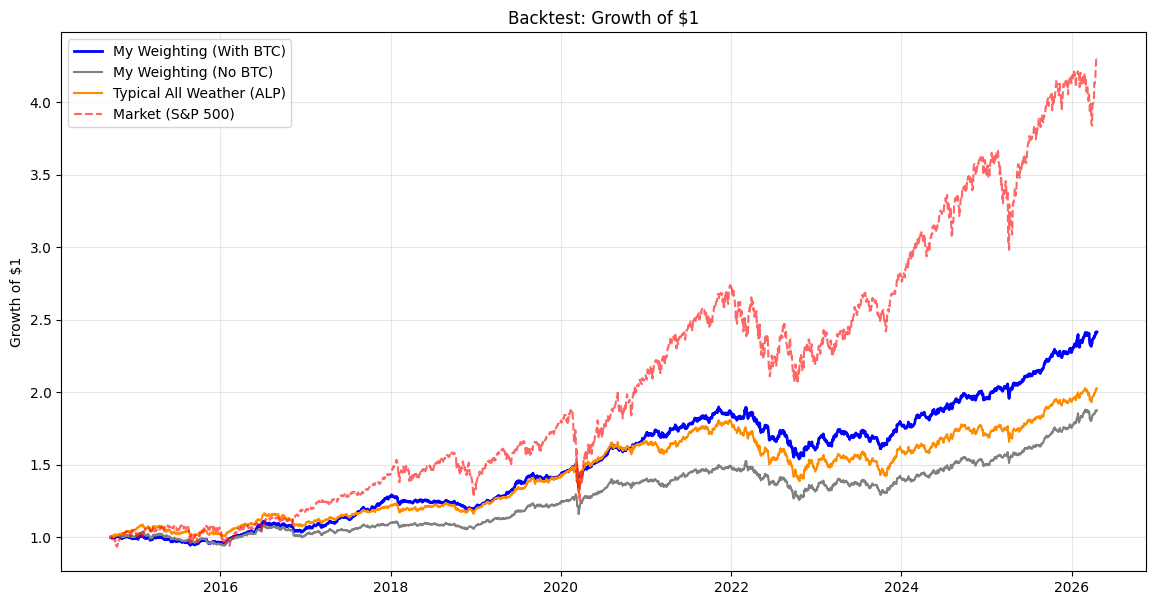

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_portfolio_analysis(file_path):
    # 1. Load and Clean Data
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    # Ensure columns match your data
    df = df.rename(columns={'close': 'btc'}).sort_values('time')

    # Define asset columns
    all_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                  'IEF - intermediate bonds', 'TLT - long term bonds', 'btc']
    no_btc_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                     'IEF - intermediate bonds', 'TLT - long term bonds']

    # 2. Calculate Daily Returns
    returns = df.set_index('time')[all_assets].pct_change().dropna()

    # 3. Calculate WHOLE Historical SD (Annualized)
    # Instead of yearly loops, we calculate the SD for the entire period
    hist_std = returns.std() * np.sqrt(252)

    # Weighting A: Your Weights (With BTC)
    inv_vol_with = 1 / hist_std
    weights_my_with_btc = inv_vol_with / inv_vol_with.sum()

    # Weighting B: Your Weights (No BTC)
    inv_vol_no = 1 / hist_std[no_btc_assets]
    weights_my_no_btc = inv_vol_no / inv_vol_no.sum()

    # Weighting C: Typical All Weather Portfolio (Dalio Template)
    weights_dalio = pd.Series({
        'SPY - stocks': 0.30,
        'TLT - long term bonds': 0.40,
        'IEF - intermediate bonds': 0.15,
        'GLD - gold': 0.075,
        'DBC - commodities': 0.075,
        'btc': 0.00
    }).reindex(all_assets).fillna(0)

    # 4. Calculate Daily Portfolio Returns
    ret_my_with = returns[all_assets].dot(weights_my_with_btc)
    ret_my_no = returns[no_btc_assets].dot(weights_my_no_btc)
    ret_dalio = returns[all_assets].dot(weights_dalio)
    ret_market = returns['SPY - stocks']

    # 5. Calculate Cumulative Growth of $1
    cum_my_with = (1 + ret_my_with).cumprod()
    cum_my_no = (1 + ret_my_no).cumprod()
    cum_dalio = (1 + ret_dalio).cumprod()
    cum_market = (1 + ret_market).cumprod()

    # 6. Performance Metrics Helper
    def get_metrics(daily, cum):
        years = (cum.index[-1] - cum.index[0]).days / 365.25
        ann_ret = ((cum.iloc[-1])**(1/years) - 1) * 100
        ann_vol = daily.std() * np.sqrt(252) * 100
        sharpe = ann_ret / ann_vol
        return {"Ann. Return (%)": ann_ret, "Ann. Volatility (%)": ann_vol, "Sharpe Ratio": sharpe}

    stats = {
        "My Weighting (With BTC)": get_metrics(ret_my_with, cum_my_with),
        "My Weighting (No BTC)": get_metrics(ret_my_no, cum_my_no),
        "Typical All Weather (ALP)": get_metrics(ret_dalio, cum_dalio),
        "Market (S&P 500)": get_metrics(ret_market, cum_market)
    }

    # 7. Visualization
    plt.figure(figsize=(14, 7))
    plt.plot(cum_my_with, label='My Weighting (With BTC)', color='blue', linewidth=2)
    plt.plot(cum_my_no, label='My Weighting (No BTC)', color='grey', linewidth=1.5)
    plt.plot(cum_dalio, label='Typical All Weather (ALP)', color='darkorange', linewidth=1.5)
    plt.plot(cum_market, label='Market (S&P 500)', color='red', linestyle='--', alpha=0.6)

    plt.title('Backtest: Growth of $1')
    plt.ylabel('Growth of $1')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    weight_comp = pd.DataFrame({
        'My Weight (With BTC)': weights_my_with_btc,
        'My Weight (No BTC)': weights_my_no_btc,
        'Typical ALP': weights_dalio
    }).fillna(0) * 100

    return pd.DataFrame(stats).T, weight_comp

# Usage:
stats_df, weights_df = run_portfolio_analysis('FINA4359 database +btc.csv')

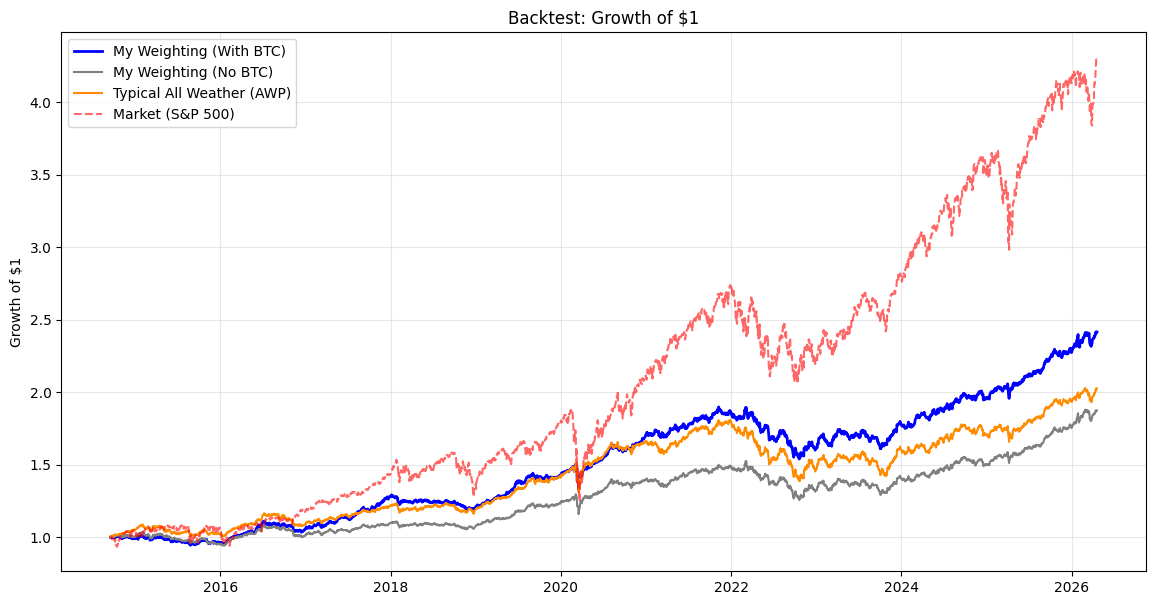

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_portfolio_analysis(file_path):
    # 1. Load and Clean Data
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    # Ensure columns match your data
    df = df.rename(columns={'close': 'btc'}).sort_values('time')

    # Define asset columns
    all_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                  'IEF - intermediate bonds', 'TLT - long term bonds', 'btc']
    no_btc_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                     'IEF - intermediate bonds', 'TLT - long term bonds']

    # 2. Calculate Daily Returns
    returns = df.set_index('time')[all_assets].pct_change().dropna()

    # 3. Calculate WHOLE Historical SD (Annualized)
    # Instead of yearly loops, we calculate the SD for the entire period
    hist_std = returns.std() * np.sqrt(252)

    # Weighting A: Your Weights (With BTC)
    inv_vol_with = 1 / hist_std
    weights_my_with_btc = inv_vol_with / inv_vol_with.sum()

    # Weighting B: Your Weights (No BTC)
    inv_vol_no = 1 / hist_std[no_btc_assets]
    weights_my_no_btc = inv_vol_no / inv_vol_no.sum()

    # Weighting C: Typical All Weather Portfolio (Dalio Template)
    weights_dalio = pd.Series({
        'SPY - stocks': 0.30,
        'TLT - long term bonds': 0.40,
        'IEF - intermediate bonds': 0.15,
        'GLD - gold': 0.075,
        'DBC - commodities': 0.075,
        'btc': 0.00
    }).reindex(all_assets).fillna(0)

    # 4. Calculate Daily Portfolio Returns
    ret_my_with = returns[all_assets].dot(weights_my_with_btc)
    ret_my_no = returns[no_btc_assets].dot(weights_my_no_btc)
    ret_dalio = returns[all_assets].dot(weights_dalio)
    ret_market = returns['SPY - stocks']

    # 5. Calculate Cumulative Growth of $1
    cum_my_with = (1 + ret_my_with).cumprod()
    cum_my_no = (1 + ret_my_no).cumprod()
    cum_dalio = (1 + ret_dalio).cumprod()
    cum_market = (1 + ret_market).cumprod()

    # 6. Performance Metrics Helper
    def get_metrics(daily, cum):
        years = (cum.index[-1] - cum.index[0]).days / 365.25
        ann_ret = ((cum.iloc[-1])**(1/years) - 1) * 100
        ann_vol = daily.std() * np.sqrt(252) * 100
        sharpe = ann_ret / ann_vol
        return {"Ann. Return (%)": ann_ret, "Ann. Volatility (%)": ann_vol, "Sharpe Ratio": sharpe}

    stats = {
        "My Weighting (With BTC)": get_metrics(ret_my_with, cum_my_with),
        "My Weighting (No BTC)": get_metrics(ret_my_no, cum_my_no),
        "Typical All Weather (ALP)": get_metrics(ret_dalio, cum_dalio),
        "Market (S&P 500)": get_metrics(ret_market, cum_market)
    }

    # 7. Visualization
    plt.figure(figsize=(14, 7))
    plt.plot(cum_my_with, label='My Weighting (With BTC)', color='blue', linewidth=2)
    plt.plot(cum_my_no, label='My Weighting (No BTC)', color='grey', linewidth=1.5)
    plt.plot(cum_dalio, label='Typical All Weather (AWP)', color='darkorange', linewidth=1.5)
    plt.plot(cum_market, label='Market (S&P 500)', color='red', linestyle='--', alpha=0.6)

    plt.title('Backtest: Growth of $1')
    plt.ylabel('Growth of $1')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    weight_comp = pd.DataFrame({
        'My Weight (With BTC)': weights_my_with_btc,
        'My Weight (No BTC)': weights_my_no_btc,
        'Typical AWP': weights_dalio
    }).fillna(0) * 100

    return pd.DataFrame(stats).T, weight_comp

# Usage:
stats_df, weights_df = run_portfolio_analysis('FINA4359 database +btc.csv')

/tmp/ipykernel_3023/3173520370.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_3023/3173520370.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_3023/3173520370.py:22: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_3023/3173520370.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_3023/3173520370.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series

--- Performance Metrics ---
With BTC - Monthly             | Return:  9.45% | Vol:  7.65% | Sharpe: 1.23
With BTC - Half-Yearly         | Return:  9.73% | Vol:  7.69% | Sharpe: 1.27
With BTC - Annual              | Return:  9.98% | Vol:  7.78% | Sharpe: 1.28
No BTC - Monthly               | Return:  6.75% | Vol:  7.19% | Sharpe: 0.94
No BTC - Half-Yearly           | Return:  6.98% | Vol:  7.24% | Sharpe: 0.96
No BTC - Annual                | Return:  6.91% | Vol:  7.32% | Sharpe: 0.94
Typical All Weather (AWP)      | Return:  6.90% | Vol:  8.68% | Sharpe: 0.80
Market (S&P 500)               | Return: 14.60% | Vol: 17.92% | Sharpe: 0.81


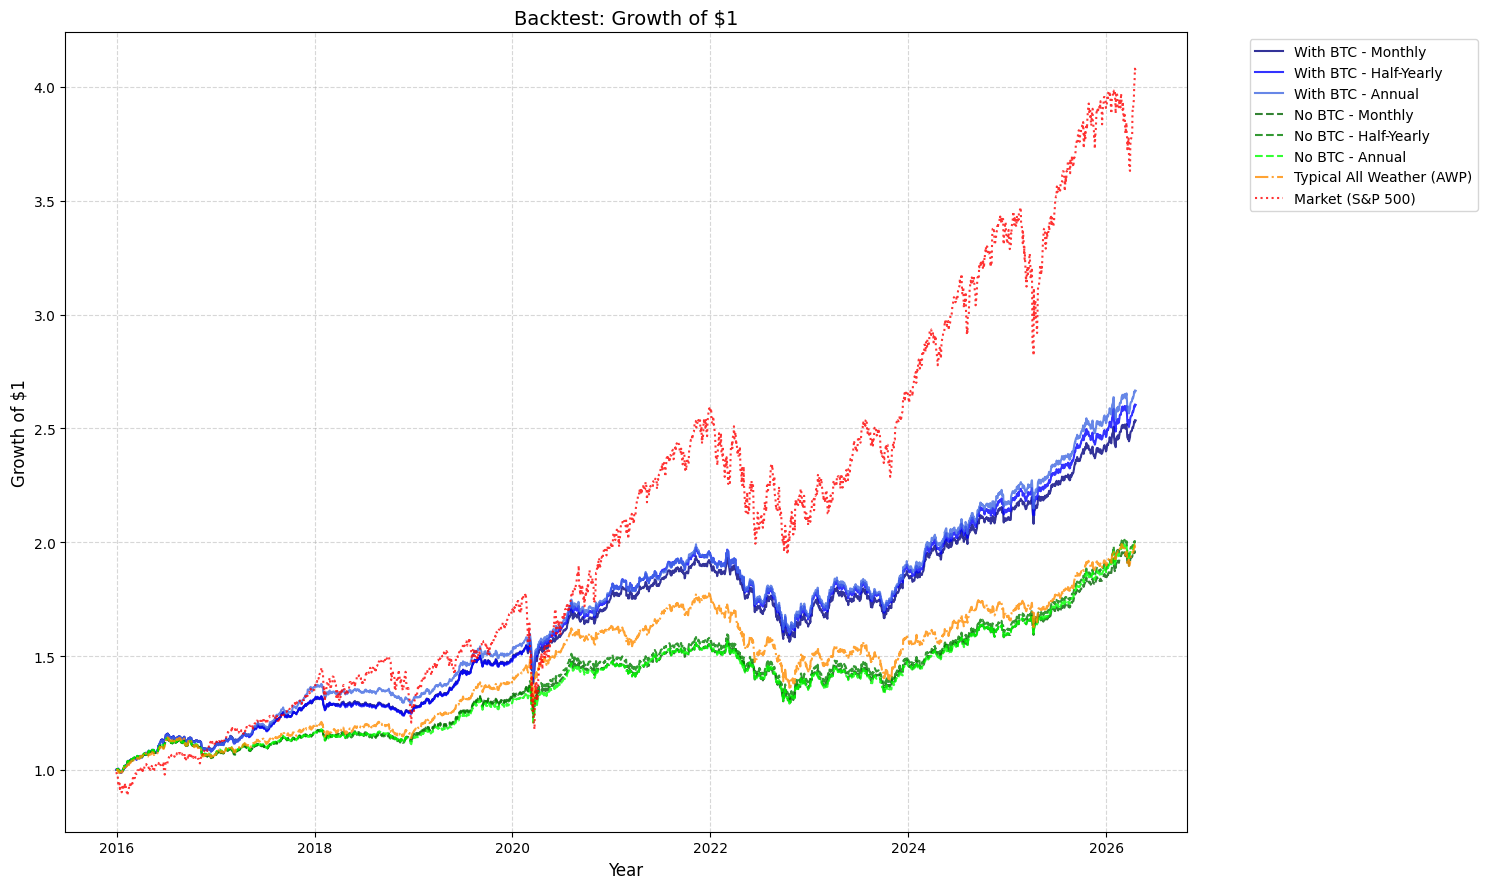

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_full_comparison(file_path):
    # 1. Data Loading
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    df = df.rename(columns={'close': 'BTC'}).sort_values('time')

    # Asset groupings
    assets_with_btc = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                       'IEF - intermediate bonds', 'TLT - long term bonds', 'btc']
    assets_no_btc = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                      'IEF - intermediate bonds', 'TLT - long term bonds']

    returns = df.set_index('time')[assets_with_btc].pct_change().dropna()

    # 2. Rebalancing Engine
    def backtest_rebalancing(returns_df, asset_list, frequency='Y', lookback=252):
        ret_sub = returns_df[asset_list]
        rebal_dates = ret_sub.index.to_series().resample(frequency).last()
        port_returns = pd.Series(index=ret_sub.index, dtype=float)
        current_weights = None

        for i in range(len(ret_sub)):
            date = ret_sub.index[i]
            if date in rebal_dates.values:
                idx = ret_sub.index.get_loc(date)
                if idx >= lookback:
                    window = ret_sub.iloc[idx - lookback : idx]
                    vols = window.std() * np.sqrt(252)
                    inv_vol = 1 / vols
                    current_weights = inv_vol / inv_vol.sum()

            if current_weights is not None:
                port_returns.iloc[i] = (ret_sub.iloc[i] * current_weights).sum()
        return port_returns.dropna()

    # 3. Generating the 8 Scenarios
    freqs = [('M', 'Monthly'), ('6M', 'Half-Yearly'), ('Y', 'Annual')]
    results = {}

    # Dynamic with BTC
    for code, name in freqs:
        results[f'With BTC - {name}'] = backtest_rebalancing(returns, assets_with_btc, frequency=code)

    # Dynamic without BTC
    for code, name in freqs:
        results[f'No BTC - {name}'] = backtest_rebalancing(returns, assets_no_btc, frequency=code)

    # Static Typical AWP (30/40/15/7.5/7.5)
    awp_weights = pd.Series({
        'SPY - stocks': 0.30, 'TLT - long term bonds': 0.40, 'IEF - intermediate bonds': 0.15,
        'GLD - gold': 0.075, 'DBC - commodities': 0.075, 'BTC': 0.0
    }).reindex(assets_with_btc).fillna(0)
    results['Typical All Weather (AWP)'] = returns.dot(awp_weights)

    # Market (S&P 500)
    results['Market (S&P 500)'] = returns['SPY - stocks']

    # 4. PLOTTING PART
    start_date = results['With BTC - Annual'].index[0] # Align to first valid data point

    plt.figure(figsize=(15, 9))

    # Define visual styles for clarity
    styles = {
        'With BTC - Monthly': {'color': 'navy', 'ls': '-'},
        'With BTC - Half-Yearly': {'color': 'blue', 'ls': '-'},
        'With BTC - Annual': {'color': 'royalblue', 'ls': '-'},
        'No BTC - Monthly': {'color': 'darkgreen', 'ls': '--'},
        'No BTC - Half-Yearly': {'color': 'green', 'ls': '--'},
        'No BTC - Annual': {'color': 'lime', 'ls': '--'},
        'Typical All Weather (AWP)': {'color': 'darkorange', 'ls': '-.'},
        'Market (S&P 500)': {'color': 'red', 'ls': ':'}
    }

    print("--- Performance Metrics ---")
    for name, s_ret in results.items():
        # Align data
        s_aligned = s_ret.loc[start_date:]
        cum_growth = (1 + s_aligned).cumprod()

        # Plotting
        style = styles.get(name, {'color': 'black', 'ls': '-'})
        plt.plot(cum_growth, label=name, color=style['color'], linestyle=style['ls'], alpha=0.8)

        # Calculate Stats for printing
        years = (cum_growth.index[-1] - cum_growth.index[0]).days / 365.25
        ann_ret = ((cum_growth.iloc[-1])**(1/years) - 1) * 100
        ann_vol = s_aligned.std() * np.sqrt(252) * 100
        sharpe = ann_ret / ann_vol
        print(f"{name:30} | Return: {ann_ret:5.2f}% | Vol: {ann_vol:5.2f}% | Sharpe: {sharpe:4.2f}")

    plt.title('Backtest: Growth of $1', fontsize=14)
    plt.ylabel('Growth of $1', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run the full script
run_full_comparison('FINA4359 database +btc.csv')

/tmp/ipykernel_3023/2334658948.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  svxy_raw = yf.download('SVXY', start=df.index.min(), end=df.index.max())
[*********************100%***********************]  1 of 1 completed

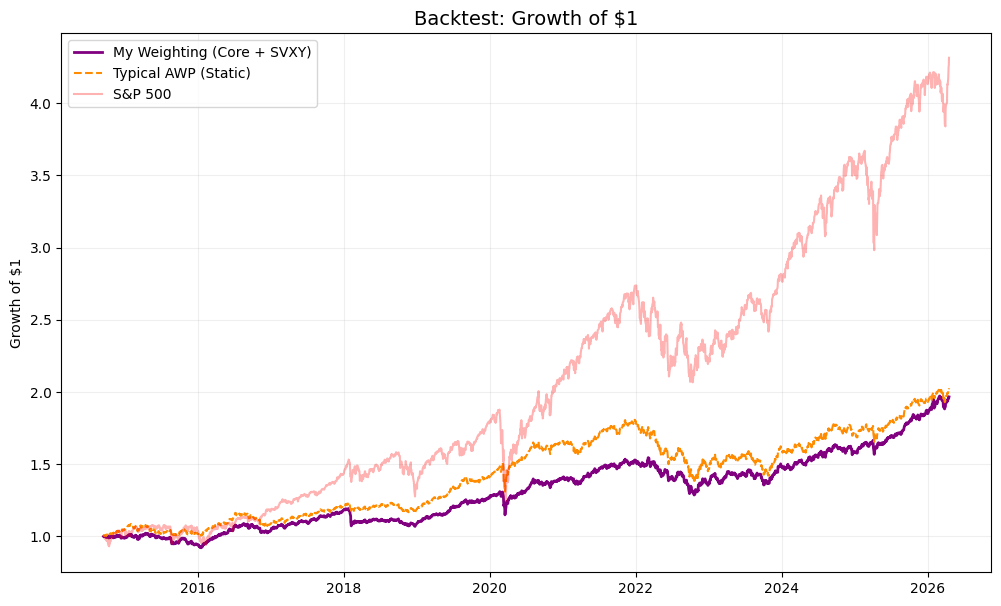


--- Optimized Static Weights ---
SPY - stocks                13.72
GLD - gold                  15.20
DBC - commodities           13.56
IEF - intermediate bonds    36.81
TLT - long term bonds       16.27
SVXY                         4.44
dtype: float64


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

def run_fixed_analysis(file_path):
    # 1. Load your file
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time').sort_index()

    # 2. Define Core Assets (Ignoring BTC as requested)
    core_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                   'IEF - intermediate bonds', 'TLT - long term bonds']

    # 3. Download SVXY (Short Volatility)
    print("Downloading SVXY data...")
    svxy_raw = yf.download('SVXY', start=df.index.min(), end=df.index.max())

    # Use 'Adj Close' and force it into a Series named 'SVXY'
    # This prevents the 'rename' error by naming the Series directly
    if isinstance(svxy_raw.columns, pd.MultiIndex):
        # Handles newer yfinance versions
        svxy_series = svxy_raw[('Close', 'SVXY')]
    else:
        svxy_series = svxy_raw['Adj Close']

    svxy_series.name = 'SVXY'

    # 4. Merge Data Robustly
    # We join only the core assets and the new SVXY series
    combined_df = df[core_assets].join(svxy_series, how='inner')
    returns = combined_df.pct_change().dropna()

    # 5. Calculate Static Weights (Inverse Historical Standard Deviation)
    # This is the "Historical SD" method you requested
    vols = returns.std() * np.sqrt(252)
    weights = (1 / vols) / (1 / vols).sum()

    # 6. Calculate Portfolio Returns
    # AWP + SVXY
    ret_awp_svxy = returns.dot(weights)

    # Typical AWP (Dalio Weights - 30/40/15/7.5/7.5)
    awp_static_weights = pd.Series({
        'SPY - stocks': 0.30, 'TLT - long term bonds': 0.40,
        'IEF - intermediate bonds': 0.15, 'GLD - gold': 0.075,
        'DBC - commodities': 0.075
    }).reindex(core_assets)
    ret_dalio = returns[core_assets].dot(awp_static_weights)

    # Market
    ret_market = returns['SPY - stocks']

    # 7. Plotting
    # We use explicit plt.plot calls to avoid any 'str object' issues
    plt.figure(figsize=(12, 7))
    plt.plot((1 + ret_awp_svxy).cumprod(), label='My Weighting (Core + SVXY)', color='purple', linewidth=2)
    plt.plot((1 + ret_dalio).cumprod(), label='Typical AWP (Static)', color='darkorange', linestyle='--')
    plt.plot((1 + ret_market).cumprod(), label='S&P 500', color='red', alpha=0.3)

    plt.title('Backtest: Growth of $1',fontsize=14)
    plt.ylabel('Growth of $1')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    print("\n--- Optimized Static Weights ---")
    print((weights * 100).round(2))

# Execute
run_fixed_analysis('FINA4359 database +btc.csv')

Loading FINA4359 database +btc.csv...


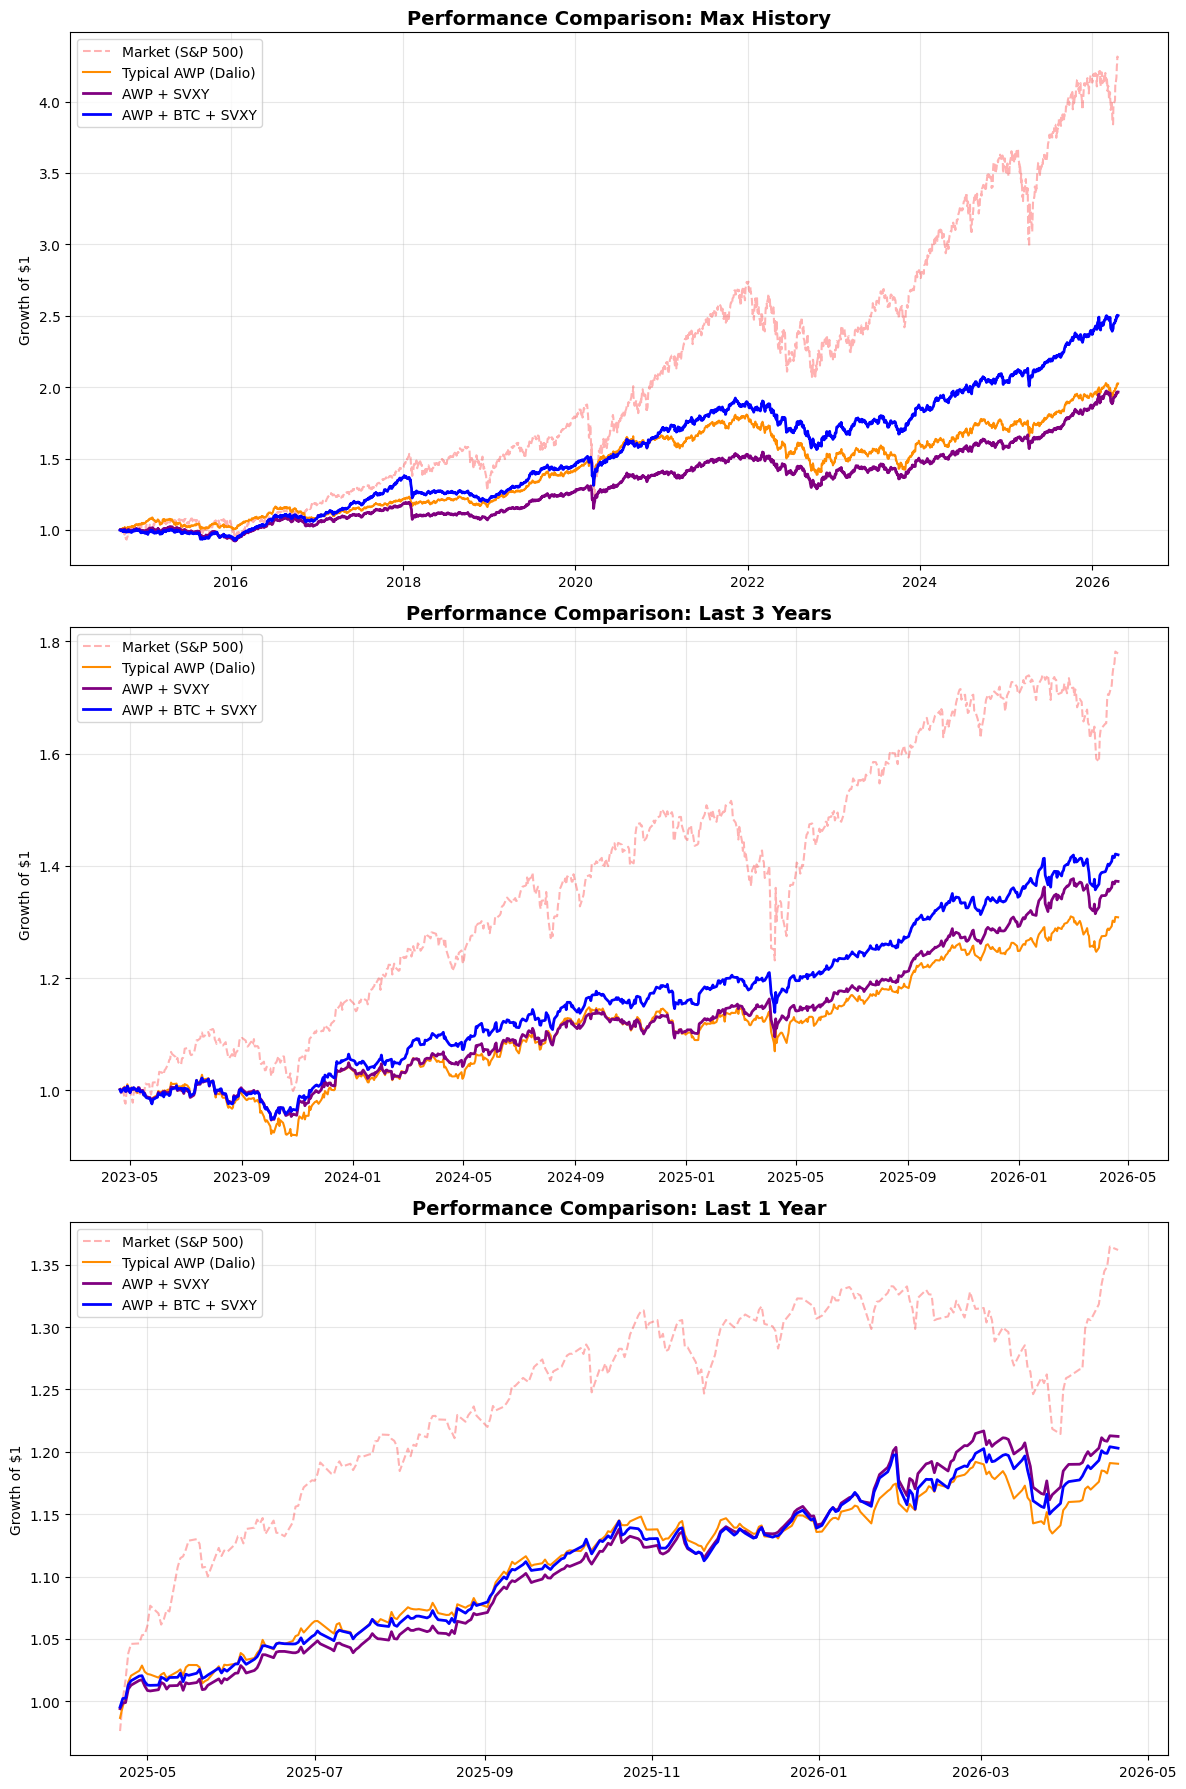


PORTFOLIO PERFORMANCE SUMMARY (Full History)
           Strategy  Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio
   Market (S&P 500)            13.43                17.62          0.76
Typical AWP (Dalio)             6.28                 8.51          0.74
         AWP + SVXY             6.01                 7.65          0.79
   AWP + BTC + SVXY             8.23                 8.06          1.02

WEIGHTS: AWP + BTC + SVXY
SPY - stocks                13.24
GLD - gold                  14.67
DBC - commodities           13.08
IEF - intermediate bonds    35.52
TLT - long term bonds       15.70
svxy                         4.28
btc                          3.51
dtype: float64


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_portfolio_analysis(file_path):
    # 1. Load Data
    print(f"Loading {file_path}...")
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time').sort_index()

    # Define asset groups based on your CSV column names
    core_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                   'IEF - intermediate bonds', 'TLT - long term bonds']
    svxy_col = 'svxy'
    btc_col = 'btc'

    # 2. Calculate Daily Returns
    # Note: We use pct_change() to get daily growth rates
    all_assets = core_assets + [svxy_col, btc_col]
    returns = df[all_assets].pct_change().dropna()

    # 3. Define Weighting Strategies

    # A: Typical AWP (Ray Dalio's fixed weights)
    dalio_weights = pd.Series({
        'SPY - stocks': 0.30,
        'TLT - long term bonds': 0.40,
        'IEF - intermediate bonds': 0.15,
        'GLD - gold': 0.075,
        'DBC - commodities': 0.075
    }).reindex(core_assets)

    # B: Risk Parity Function (Inverse Volatility Weighting)
    def get_risk_parity_weights(rets, asset_list):
        # Annualized Standard Deviation
        vols = rets[asset_list].std() * np.sqrt(252)
        inv_vol = 1 / vols
        return inv_vol / inv_vol.sum()

    # Calculate weights for your custom portfolios
    weights_svxy_only = get_risk_parity_weights(returns, core_assets + [svxy_col])
    weights_full = get_risk_parity_weights(returns, core_assets + [svxy_col, btc_col])

    # 4. Calculate Daily Portfolio Returns
    portfolio_returns = pd.DataFrame(index=returns.index)
    portfolio_returns['Market (S&P 500)'] = returns['SPY - stocks']
    portfolio_returns['Typical AWP (Dalio)'] = returns[core_assets].dot(dalio_weights)
    portfolio_returns['AWP + SVXY'] = returns[core_assets + [svxy_col]].dot(weights_svxy_only)
    portfolio_returns['AWP + BTC + SVXY'] = returns[all_assets].dot(weights_full)

    # 5. Define Timeframes for Plotting
    last_date = portfolio_returns.index[-1]
    timeframes = {
        "Max History": portfolio_returns.index[0],
        "Last 3 Years": last_date - pd.DateOffset(years=3),
        "Last 1 Year": last_date - pd.DateOffset(years=1)
    }

    # 6. Generate the Triple-Timeframe Plot
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))

    for i, (label, start_date) in enumerate(timeframes.items()):
        # Filter data for the timeframe
        window_rets = portfolio_returns.loc[start_date:]
        cum_growth = (1 + window_rets).cumprod()

        ax = axes[i]
        ax.plot(cum_growth['Market (S&P 500)'], label='Market (S&P 500)', color='red', alpha=0.3, linestyle='--')
        ax.plot(cum_growth['Typical AWP (Dalio)'], label='Typical AWP (Dalio)', color='darkorange', linewidth=1.5)
        ax.plot(cum_growth['AWP + SVXY'], label='AWP + SVXY', color='purple', linewidth=2)
        ax.plot(cum_growth['AWP + BTC + SVXY'], label='AWP + BTC + SVXY', color='blue', linewidth=2)

        ax.set_title(f'Performance Comparison: {label}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Growth of $1')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 7. Print Performance Metrics Summary
    print("\n" + "="*50)
    print("PORTFOLIO PERFORMANCE SUMMARY (Full History)")
    print("="*50)

    metrics = []
    for col in portfolio_returns.columns:
        daily_ret = portfolio_returns[col]
        cum_ret = (1 + daily_ret).cumprod()

        years = (cum_ret.index[-1] - cum_ret.index[0]).days / 365.25
        ann_return = (cum_ret.iloc[-1]**(1/years) - 1) * 100
        ann_vol = daily_ret.std() * np.sqrt(252) * 100
        sharpe = ann_return / ann_vol

        metrics.append({
            'Strategy': col,
            'Ann. Return (%)': round(ann_return, 2),
            'Ann. Volatility (%)': round(ann_vol, 2),
            'Sharpe Ratio': round(sharpe, 2)
        })

    print(pd.DataFrame(metrics).to_string(index=False))

    print("\n" + "="*50)
    print("WEIGHTS: AWP + BTC + SVXY")
    print("="*50)
    print((weights_full * 100).round(2))

# --- RUN THE CODE ---
run_portfolio_analysis('FINA4359 database +btc.csv')